In [ ]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = "./data/DREAMER.mat"

mat = sio.loadmat(file_path)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'DREAMER'])


In [3]:
dreamer = mat["DREAMER"]

print(type(dreamer))
print(dreamer.dtype)

<class 'numpy.ndarray'>
[('Data', 'O'), ('EEG_SamplingRate', 'O'), ('ECG_SamplingRate', 'O'), ('EEG_Electrodes', 'O'), ('noOfSubjects', 'O'), ('noOfVideoSequences', 'O'), ('Disclaimer', 'O'), ('Provider', 'O'), ('Version', 'O'), ('Acknowledgement', 'O')]


In [ ]:

mat = sio.loadmat(
    "DREAMER.mat",
    squeeze_me=True,
    struct_as_record=False
)

dreamer = mat["DREAMER"]

print("Number of subjects:", dreamer.noOfSubjects)
print("Number of videos:", dreamer.noOfVideoSequences)
print("EEG sampling rate:", dreamer.EEG_SamplingRate)
print("EEG electrodes:", dreamer.EEG_Electrodes)

Number of subjects: 23
Number of videos: 18
EEG sampling rate: 128
EEG electrodes: ['AF3' 'F7' 'F3' 'FC5' 'T7' 'P7' 'O1' 'O2' 'P8' 'T8' 'FC6' 'F4' 'F8' 'AF4']


In [5]:
# اطلاعات Subject اول
subject1 = dreamer.Data[0]

print("Age:", subject1.Age)
print("Gender:", subject1.Gender)

print("\nValence:")
print(subject1.ScoreValence)

print("\nArousal:")
print(subject1.ScoreArousal)

print("\nDominance:")
print(subject1.ScoreDominance)

Age: 22
Gender: male

Valence:
[4 3 5 4 4 1 5 1 1 5 4 4 4 3 2 3 1 3]

Arousal:
[3 3 4 3 4 2 4 2 2 3 2 3 3 1 5 2 2 5]

Dominance:
[2 1 4 2 4 5 4 4 3 4 3 4 2 2 5 2 5 5]


In [6]:
# ============================================================
# استخراج V/A/D از تمام 23 Subject و 18 Video
# ============================================================

all_data = []

for subject_idx in range(dreamer.noOfSubjects):

    subject = dreamer.Data[subject_idx]

    valence = np.asarray(subject.ScoreValence).flatten()
    arousal = np.asarray(subject.ScoreArousal).flatten()
    dominance = np.asarray(subject.ScoreDominance).flatten()

    for video_idx in range(dreamer.noOfVideoSequences):

        all_data.append({
            "Subject": subject_idx + 1,
            "Video": video_idx + 1,
            "Valence": valence[video_idx],
            "Arousal": arousal[video_idx],
            "Dominance": dominance[video_idx]
        })


# تبدیل به DataFrame
df = pd.DataFrame(all_data)

print("Number of points:", len(df))
print()
print(df.head(10))


Number of points: 414

   Subject  Video  Valence  Arousal  Dominance
0        1      1        4        3          2
1        1      2        3        3          1
2        1      3        5        4          4
3        1      4        4        3          2
4        1      5        4        4          4
5        1      6        1        2          5
6        1      7        5        4          4
7        1      8        1        2          4
8        1      9        1        2          3
9        1     10        5        3          4


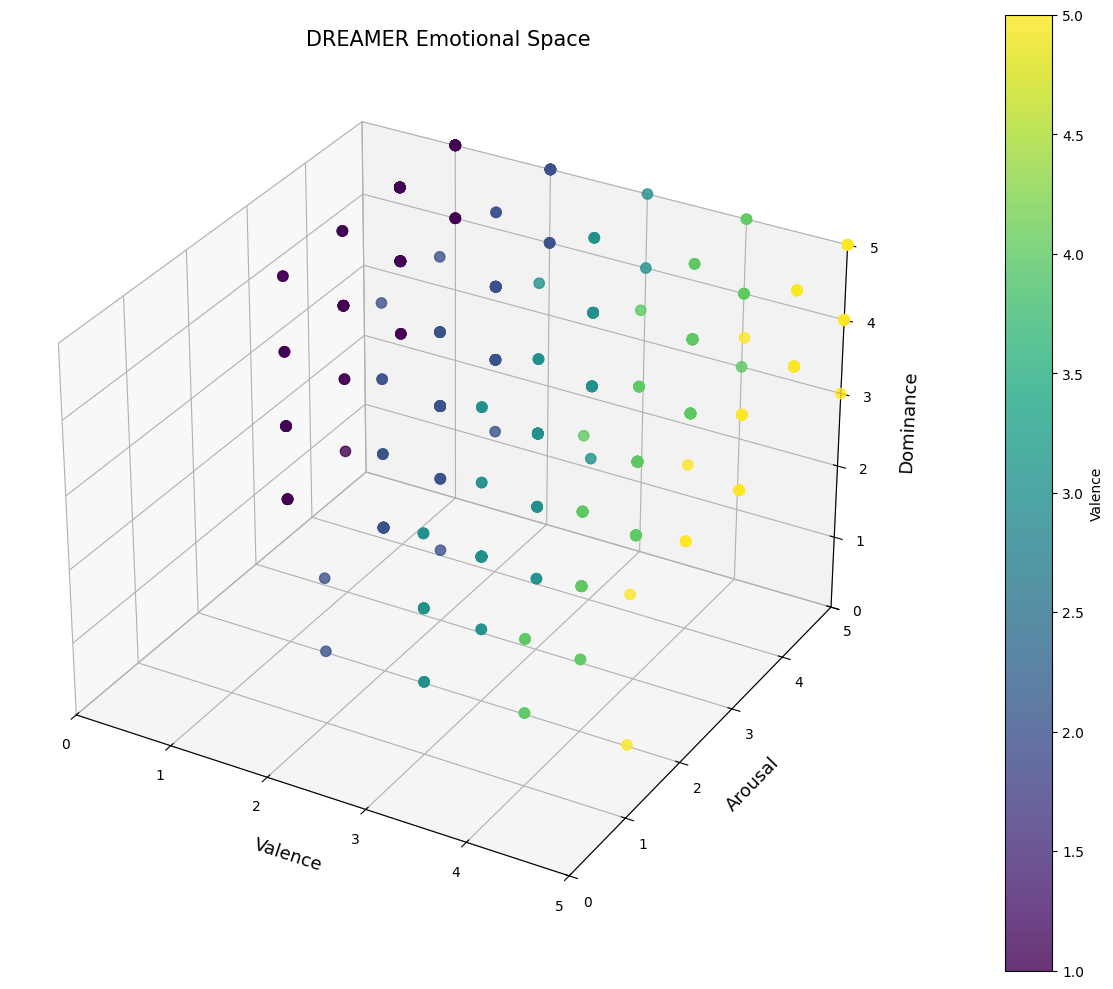

In [10]:
fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["Valence"],
    df["Arousal"],
    df["Dominance"],
    c=df["Valence"],
    cmap="viridis",
    s=55,
    alpha=0.8
)

# محدوده از صفر
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_zlim(0, 5)

# تیک‌ها
ax.set_xticks(range(0, 6))
ax.set_yticks(range(0, 6))
ax.set_zticks(range(0, 6))

# نام محورها
ax.set_xlabel("Valence", fontsize=13, labelpad=10)
ax.set_ylabel("Arousal", fontsize=13, labelpad=10)
ax.set_zlabel("Dominance", fontsize=13, labelpad=10)

ax.set_title(
    "DREAMER Emotional Space",
    fontsize=15
)

cbar = plt.colorbar(
    scatter,
    ax=ax,
    pad=0.1
)

cbar.set_label("Valence")

plt.tight_layout()
plt.show()